# Learner Demographics and Course Enrollment Behavior Analysis on EduPro

## Submitted By:
Afsha Sayyed

## Course:
Machine Learning

## Organization:
Unified Mentor

## Project Domain:
Education Analytics

## Introduction

Online learning platforms generate large volumes of learner and course enrollment data. Analyzing this data helps educational platforms understand learner behavior, identify popular course categories, and make informed decisions regarding course offerings and marketing strategies.

This project focuses on analyzing learner demographics and enrollment behavior for the EduPro online learning platform. Using multiple datasets containing user information, course details, and enrollment transactions, the project aims to identify meaningful trends and provide business insights that can support data-driven decision-making.

## Problem Statement

EduPro currently possesses large amounts of learner and course enrollment data but lacks meaningful insights regarding learner demographics and enrollment patterns.

The organization wants to understand:

- Which age groups are most active on the platform.
- How enrollment patterns vary across genders.
- Which course categories attract the highest number of learners.
- Whether learners at different experience levels prefer different types of courses.

Without these insights, business decisions regarding course development, learner engagement, and marketing remain largely intuition-driven instead of being supported by data.

## Objectives

The primary objectives of this project are:

• To analyze learner demographics.

• To study age-wise learner distribution.

• To examine gender participation across the platform.

• To analyze course enrollment patterns.

• To identify the most popular course categories and levels.

• To understand learner preferences across different demographic groups.

• To generate meaningful business insights through exploratory data analysis.

• To develop an interactive Streamlit dashboard for visualization and reporting.

## Import Required Libraries

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display graphs inside Jupyter Notebook
%matplotlib inline

# Ignore warning messages
import warnings
warnings.filterwarnings("ignore")

## Load the Datasets

In [2]:
# Load Users Dataset
users_df = pd.read_csv("EduProUsers.csv")

# Load Courses Dataset
courses_df = pd.read_csv("EduProCourses.csv")

# Load Transactions Dataset
transactions_df = pd.read_csv("EduProTransactions.csv")

# Load Teachers Dataset
teachers_df = pd.read_csv("EduProTeachers.csv")

## Display First Five Records

In [3]:
print("Users Dataset")
display(users_df.head())

print("Courses Dataset")
display(courses_df.head())

print("Transactions Dataset")
display(transactions_df.head())

print("Teachers Dataset")
display(teachers_df.head())

Users Dataset


,UserID,UserName,Age,Gender,Email
0,U00001,wilsonjordan,15,Male,patricia27@hotmail.com
1,U00002,angela22,29,Female,hallrandy@hotmail.com
2,U00003,morrisonamanda,33,Female,ganderson@yahoo.com
3,U00004,fthornton,23,Female,christensencatherine@outlook.com
4,U00005,fostergeoffrey,21,Male,karenfuentes@yahoo.com


Courses Dataset


,CourseID,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating
0,CR00001,Python Basics,Programming,Paid,Beginner,472.28,11.00,4.74
1,CR00002,Java Programming,Programming,Free,Intermediate,0.00,37.70,2.43
2,CR00003,C++ for Beginners,Programming,Free,Beginner,0.00,19.53,3.85
3,CR00004,Advanced Python,Programming,Free,Beginner,0.00,45.13,2.88
4,CR00005,Full Stack Development,Programming,Free,Beginner,0.00,28.68,1.28


Transactions Dataset


,TransactionID,UserID,CourseID,TransactionDate,Amount,PaymentMethod,TeacherID
0,TT00001,U00003,CR00016,25/10/2025,0.0,PayPal,TC00040
1,TT00002,U00003,CR00037,13/1/2025,0.0,PayPal,TC00040
2,TT00003,U00003,CR00019,28/3/2025,0.0,Bank Transfer,TC00040
3,TT00004,U00004,CR00048,2/6/2025,0.0,Bank Transfer,TC00040
4,TT00005,U00004,CR00060,10/8/2025,0.0,PayPal,TC00042


Teachers Dataset


,TeacherID,TeacherName,Age,Gender,Expertise,YearsOfExperience,TeacherRating
0,TC00001,Leonard Montgomery,44,Female,Cybersecurity,6,3.24
1,TC00002,Jill Day,32,Female,Digital Marketing,9,4.14
2,TC00003,Amber Torres,32,Male,Design,4,1.56
3,TC00004,Kristi Scott,34,Female,Machine Learning,9,4.39
4,TC00005,David Williams,34,Male,Finance,2,3.11


## Check Dataset Dimensions

In [4]:
print("Users Dataset Shape:", users_df.shape)
print("Courses Dataset Shape:", courses_df.shape)
print("Transactions Dataset Shape:", transactions_df.shape)
print("Teachers Dataset Shape:", teachers_df.shape)

Users Dataset Shape: (3000, 5)
Courses Dataset Shape: (60, 8)
Transactions Dataset Shape: (10000, 7)
Teachers Dataset Shape: (60, 7)


## Dataset Information

In [5]:
print("Users Dataset")
users_df.info()

print("\nCourses Dataset")
courses_df.info()

print("\nTransactions Dataset")
transactions_df.info()

print("\nTeachers Dataset")
teachers_df.info()

Users Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   UserID    3000 non-null   object
 1   UserName  3000 non-null   object
 2   Age       3000 non-null   int64 
 3   Gender    3000 non-null   object
 4   Email     3000 non-null   object
dtypes: int64(1), object(4)
memory usage: 117.3+ KB

Courses Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CourseID        60 non-null     object 
 1   CourseName      60 non-null     object 
 2   CourseCategory  60 non-null     object 
 3   CourseType      60 non-null     object 
 4   CourseLevel     60 non-null     object 
 5   CoursePrice     60 non-null     float64
 6   CourseDuration  60 non-null     float64
 7   CourseRating    60 non-null     f

## Display Column Names

In [6]:
print("Users Columns")
print(users_df.columns.tolist())

print("\nCourses Columns")
print(courses_df.columns.tolist())

print("\nTransactions Columns")
print(transactions_df.columns.tolist())

print("\nTeachers Columns")
print(teachers_df.columns.tolist())

Users Columns
['UserID', 'UserName', 'Age', 'Gender', 'Email']

Courses Columns
['CourseID', 'CourseName', 'CourseCategory', 'CourseType', 'CourseLevel', 'CoursePrice', 'CourseDuration', 'CourseRating']

Transactions Columns
['TransactionID', 'UserID', 'CourseID', 'TransactionDate', 'Amount', 'PaymentMethod', 'TeacherID']

Teachers Columns
['TeacherID', 'TeacherName', 'Age', 'Gender', 'Expertise', 'YearsOfExperience', 'TeacherRating']


# Chapter 2: Data Quality Assessment and Cleaning


## 2.1 Checking Missing Values

In [7]:
print("Missing Values in Users Dataset")
print(users_df.isnull().sum())

print("\nMissing Values in Courses Dataset")
print(courses_df.isnull().sum())

print("\nMissing Values in Transactions Dataset")
print(transactions_df.isnull().sum())

print("\nMissing Values in Teachers Dataset")
print(teachers_df.isnull().sum())

Missing Values in Users Dataset
UserID      0
UserName    0
Age         0
Gender      0
Email       0
dtype: int64

Missing Values in Courses Dataset
CourseID          0
CourseName        0
CourseCategory    0
CourseType        0
CourseLevel       0
CoursePrice       0
CourseDuration    0
CourseRating      0
dtype: int64

Missing Values in Transactions Dataset
TransactionID      0
UserID             0
CourseID           0
TransactionDate    0
Amount             0
PaymentMethod      0
TeacherID          0
dtype: int64

Missing Values in Teachers Dataset
TeacherID            0
TeacherName          0
Age                  0
Gender               0
Expertise            0
YearsOfExperience    0
TeacherRating        0
dtype: int64


## 2.2 Checking Duplicate Records

In [8]:
print("Duplicate Rows in Users Dataset :", users_df.duplicated().sum())

print("Duplicate Rows in Courses Dataset :", courses_df.duplicated().sum())

print("Duplicate Rows in Transactions Dataset :", transactions_df.duplicated().sum())

print("Duplicate Rows in Teachers Dataset :", teachers_df.duplicated().sum())

Duplicate Rows in Users Dataset : 0
Duplicate Rows in Courses Dataset : 0
Duplicate Rows in Transactions Dataset : 0
Duplicate Rows in Teachers Dataset : 0


In [9]:
users_df.drop_duplicates(inplace=True)

courses_df.drop_duplicates(inplace=True)

transactions_df.drop_duplicates(inplace=True)

teachers_df.drop_duplicates(inplace=True)

## 2.3 Verifying Data Types

In [10]:
print(users_df.dtypes)

print("\n")

print(courses_df.dtypes)

print("\n")

print(transactions_df.dtypes)

print("\n")

print(teachers_df.dtypes)

UserID      object
UserName    object
Age          int64
Gender      object
Email       object
dtype: object


CourseID           object
CourseName         object
CourseCategory     object
CourseType         object
CourseLevel        object
CoursePrice       float64
CourseDuration    float64
CourseRating      float64
dtype: object


TransactionID       object
UserID              object
CourseID            object
TransactionDate     object
Amount             float64
PaymentMethod       object
TeacherID           object
dtype: object


TeacherID             object
TeacherName           object
Age                    int64
Gender                object
Expertise             object
YearsOfExperience      int64
TeacherRating        float64
dtype: object


In [11]:
transactions_df["TransactionDate"] = pd.to_datetime(
    transactions_df["TransactionDate"]
)

In [12]:
transactions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   TransactionID    10000 non-null  object        
 1   UserID           10000 non-null  object        
 2   CourseID         10000 non-null  object        
 3   TransactionDate  10000 non-null  datetime64[ns]
 4   Amount           10000 non-null  float64       
 5   PaymentMethod    10000 non-null  object        
 6   TeacherID        10000 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(5)
memory usage: 547.0+ KB


## 2.4 Checking Unique Values

In [13]:
print("Gender")
print(users_df["Gender"].unique())

print("\nCourse Categories")
print(courses_df["CourseCategory"].unique())

print("\nCourse Type")
print(courses_df["CourseType"].unique())

print("\nCourse Level")
print(courses_df["CourseLevel"].unique())

Gender
['Male' 'Female']

Course Categories
['Programming' 'Design' 'Business' 'Marketing' 'Data Science'
 'Machine Learning' 'Cybersecurity' 'Project Management' 'Finance'
 'Artificial Intelligence' 'Web Development' 'Digital Marketing']

Course Type
['Paid' 'Free']

Course Level
['Beginner' 'Intermediate' 'Advanced']


In [14]:
users_df["Gender"] = users_df["Gender"].str.strip().str.title()

courses_df["CourseCategory"] = (
    courses_df["CourseCategory"]
    .str.strip()
    .str.title()
)

courses_df["CourseType"] = (
    courses_df["CourseType"]
    .str.strip()
    .str.title()
)

courses_df["CourseLevel"] = (
    courses_df["CourseLevel"]
    .str.strip()
    .str.title()
)

## 2.5 Validating Age Values

In [15]:
print(users_df["Age"].describe())

count    3000.000000
mean       24.974333
std         6.046475
min        15.000000
25%        20.000000
50%        25.000000
75%        30.000000
max        35.000000
Name: Age, dtype: float64


In [16]:
users_df[
    (users_df["Age"] < 10)
    |
    (users_df["Age"] > 100)
]

,UserID,UserName,Age,Gender,Email


In [17]:
print(
    "Duplicate User IDs:",
    users_df["UserID"].duplicated().sum()
)

Duplicate User IDs: 0


In [18]:
print(
    "Duplicate Course IDs:",
    courses_df["CourseID"].duplicated().sum()
)

Duplicate Course IDs: 0


In [19]:
print(
    "Duplicate Transaction IDs:",
    transactions_df["TransactionID"].duplicated().sum()
)

Duplicate Transaction IDs: 0


In [20]:
invalid_users = transactions_df[
    ~transactions_df["UserID"].isin(users_df["UserID"])
]

print("Transactions with Invalid User IDs:")
print(invalid_users)

Transactions with Invalid User IDs:
Empty DataFrame
Columns: [TransactionID, UserID, CourseID, TransactionDate, Amount, PaymentMethod, TeacherID]
Index: []


In [21]:
invalid_courses = transactions_df[
    ~transactions_df["CourseID"].isin(courses_df["CourseID"])
]

print("Transactions with Invalid Course IDs:")
print(invalid_courses)

Transactions with Invalid Course IDs:
Empty DataFrame
Columns: [TransactionID, UserID, CourseID, TransactionDate, Amount, PaymentMethod, TeacherID]
Index: []


In [22]:
print(users_df.describe(include="all"))

print(courses_df.describe(include="all"))

print(transactions_df.describe(include="all"))

print(teachers_df.describe(include="all"))

        UserID      UserName          Age  Gender                   Email
count     3000          3000  3000.000000    3000                    3000
unique    3000          3000          NaN       2                    3000
top     U00001  wilsonjordan          NaN  Female  patricia27@hotmail.com
freq         1             1          NaN    1520                       1
mean       NaN           NaN    24.974333     NaN                     NaN
std        NaN           NaN     6.046475     NaN                     NaN
min        NaN           NaN    15.000000     NaN                     NaN
25%        NaN           NaN    20.000000     NaN                     NaN
50%        NaN           NaN    25.000000     NaN                     NaN
75%        NaN           NaN    30.000000     NaN                     NaN
max        NaN           NaN    35.000000     NaN                     NaN
       CourseID                   CourseName CourseCategory CourseType  \
count        60                       

# Chapter 3: Data Integration

In [23]:
print("Users Dataset Key")
print(users_df["UserID"].head())

print("\nTransactions UserID")
print(transactions_df["UserID"].head())

print("\nCourses Dataset Key")
print(courses_df["CourseID"].head())

print("\nTransactions CourseID")
print(transactions_df["CourseID"].head())

Users Dataset Key
0    U00001
1    U00002
2    U00003
3    U00004
4    U00005
Name: UserID, dtype: object

Transactions UserID
0    U00003
1    U00003
2    U00003
3    U00004
4    U00004
Name: UserID, dtype: object

Courses Dataset Key
0    CR00001
1    CR00002
2    CR00003
3    CR00004
4    CR00005
Name: CourseID, dtype: object

Transactions CourseID
0    CR00016
1    CR00037
2    CR00019
3    CR00048
4    CR00060
Name: CourseID, dtype: object


## Merge Users and Transactions

In [24]:
user_transactions = pd.merge(
    users_df,
    transactions_df,
    on="UserID",
    how="inner"
)

print(user_transactions.shape)

user_transactions.head()

(10000, 11)


,UserID,UserName,Age,Gender,Email,TransactionID,CourseID,TransactionDate,Amount,PaymentMethod,TeacherID
0,U00001,wilsonjordan,15,Male,patricia27@hotmail.com,TT02675,CR00034,2025-11-02,394.26,PayPal,TC00031
1,U00002,angela22,29,Female,hallrandy@hotmail.com,TT02676,CR00004,2025-07-15,0.00,PayPal,TC00009
2,U00003,morrisonamanda,33,Female,ganderson@yahoo.com,TT00001,CR00016,2025-10-25,0.00,PayPal,TC00040
3,U00003,morrisonamanda,33,Female,ganderson@yahoo.com,TT00002,CR00037,2025-01-13,0.00,PayPal,TC00040
4,U00003,morrisonamanda,33,Female,ganderson@yahoo.com,TT00003,CR00019,2025-03-28,0.00,Bank Transfer,TC00040


## Merge with Courses Dataset

In [25]:
merged_df = pd.merge(
    user_transactions,
    courses_df,
    on="CourseID",
    how="inner"
)

print(merged_df.shape)

merged_df.head()

(10000, 18)


,UserID,UserName,Age,Gender,Email,TransactionID,CourseID,TransactionDate,Amount,PaymentMethod,TeacherID,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating
0,U00001,wilsonjordan,15,Male,patricia27@hotmail.com,TT02675,CR00034,2025-11-02,394.26,PayPal,TC00031,Data Encryption,Cybersecurity,Paid,Intermediate,394.26,47.44,1.35
1,U00002,angela22,29,Female,hallrandy@hotmail.com,TT02676,CR00004,2025-07-15,0.00,PayPal,TC00009,Advanced Python,Programming,Free,Beginner,0.00,45.13,2.88
2,U00003,morrisonamanda,33,Female,ganderson@yahoo.com,TT00001,CR00016,2025-10-25,0.00,PayPal,TC00040,Digital Marketing,Marketing,Free,Intermediate,0.00,42.68,4.72
3,U00003,morrisonamanda,33,Female,ganderson@yahoo.com,TT00002,CR00037,2025-01-13,0.00,PayPal,TC00040,Scrum Essentials,Project Management,Free,Intermediate,0.00,33.93,3.45
4,U00003,morrisonamanda,33,Female,ganderson@yahoo.com,TT00003,CR00019,2025-03-28,0.00,Bank Transfer,TC00040,Content Marketing,Marketing,Free,Advanced,0.00,18.00,2.98


In [26]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   UserID           10000 non-null  object        
 1   UserName         10000 non-null  object        
 2   Age              10000 non-null  int64         
 3   Gender           10000 non-null  object        
 4   Email            10000 non-null  object        
 5   TransactionID    10000 non-null  object        
 6   CourseID         10000 non-null  object        
 7   TransactionDate  10000 non-null  datetime64[ns]
 8   Amount           10000 non-null  float64       
 9   PaymentMethod    10000 non-null  object        
 10  TeacherID        10000 non-null  object        
 11  CourseName       10000 non-null  object        
 12  CourseCategory   10000 non-null  object        
 13  CourseType       10000 non-null  object        
 14  CourseLevel      10000 non-null  object

In [27]:
print(merged_df.columns.tolist())

['UserID', 'UserName', 'Age', 'Gender', 'Email', 'TransactionID', 'CourseID', 'TransactionDate', 'Amount', 'PaymentMethod', 'TeacherID', 'CourseName', 'CourseCategory', 'CourseType', 'CourseLevel', 'CoursePrice', 'CourseDuration', 'CourseRating']


In [28]:
merged_df.isnull().sum()

UserID             0
UserName           0
Age                0
Gender             0
Email              0
TransactionID      0
CourseID           0
TransactionDate    0
Amount             0
PaymentMethod      0
TeacherID          0
CourseName         0
CourseCategory     0
CourseType         0
CourseLevel        0
CoursePrice        0
CourseDuration     0
CourseRating       0
dtype: int64

In [29]:
merged_df.to_csv("EduPro_Merged_Dataset.csv", index=False)

print("Merged dataset saved successfully.")

Merged dataset saved successfully.


In [30]:
print("Number of Unique Users :", merged_df["UserID"].nunique())

print("Number of Unique Courses :", merged_df["CourseID"].nunique())

print("Number of Transactions :", merged_df["TransactionID"].nunique())

Number of Unique Users : 3000
Number of Unique Courses : 60
Number of Transactions : 10000


# Chapter 4: Exploratory Data Analysis (EDA)


## 4.1 Overview of the Integrated Dataset

In [31]:
print("Total Records :", merged_df.shape[0])

print("Total Features :", merged_df.shape[1])

print("Unique Learners :", merged_df["UserID"].nunique())

print("Unique Courses :", merged_df["CourseID"].nunique())

print("Total Transactions :", merged_df["TransactionID"].nunique())

Total Records : 10000
Total Features : 18
Unique Learners : 3000
Unique Courses : 60
Total Transactions : 10000


## 4.2 Age Distribution of Learners

In [32]:
age_bins = [0,17,25,35,45,100]

age_labels = [
    "<18",
    "18-25",
    "26-35",
    "36-45",
    "45+"
]

merged_df["AgeGroup"] = pd.cut(
    merged_df["Age"],
    bins=age_bins,
    labels=age_labels
)

In [33]:
age_group_counts = merged_df["AgeGroup"].value_counts().sort_index()

print(age_group_counts)

AgeGroup
<18      1469
18-25    3732
26-35    4799
36-45       0
45+         0
Name: count, dtype: int64


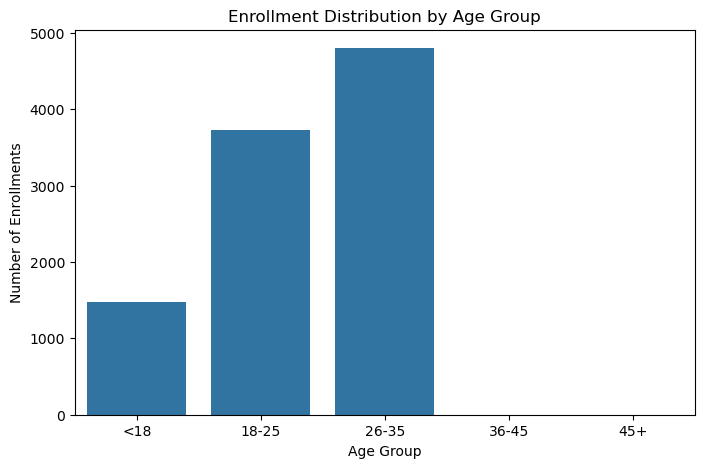

In [34]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=merged_df,
    x="AgeGroup",
    order=age_labels
)

plt.title("Enrollment Distribution by Age Group")

plt.xlabel("Age Group")

plt.ylabel("Number of Enrollments")

plt.show()

## 4.3 Gender Distribution

In [35]:
gender_counts = merged_df["Gender"].value_counts()

print(gender_counts)

Gender
Female    5078
Male      4922
Name: count, dtype: int64


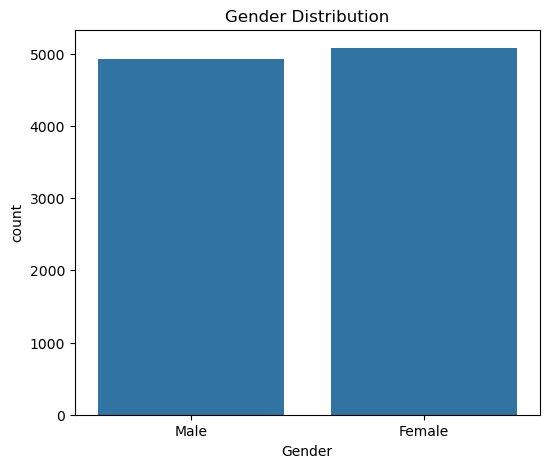

In [36]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=merged_df,
    x="Gender"
)

plt.title("Gender Distribution")

plt.show()

## 4.4 Course Category Popularity

In [37]:
category_counts = merged_df["CourseCategory"].value_counts()

print(category_counts)

CourseCategory
Data Science               916
Finance                    864
Web Development            844
Business                   833
Project Management         829
Artificial Intelligence    829
Design                     827
Cybersecurity              819
Machine Learning           819
Digital Marketing          808
Programming                806
Marketing                  806
Name: count, dtype: int64


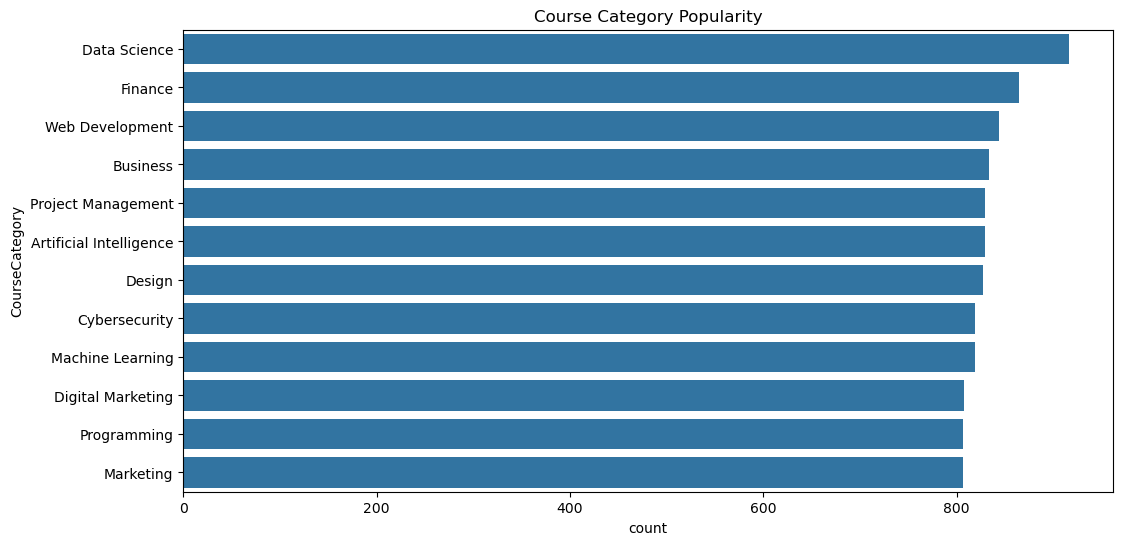

In [38]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=merged_df,
    y="CourseCategory",
    order=merged_df["CourseCategory"].value_counts().index
)

plt.title("Course Category Popularity")

plt.show()

## 4.5 Course Level Distribution

In [39]:
level_counts = merged_df["CourseLevel"].value_counts()

print(level_counts)

CourseLevel
Beginner        3573
Advanced        3475
Intermediate    2952
Name: count, dtype: int64


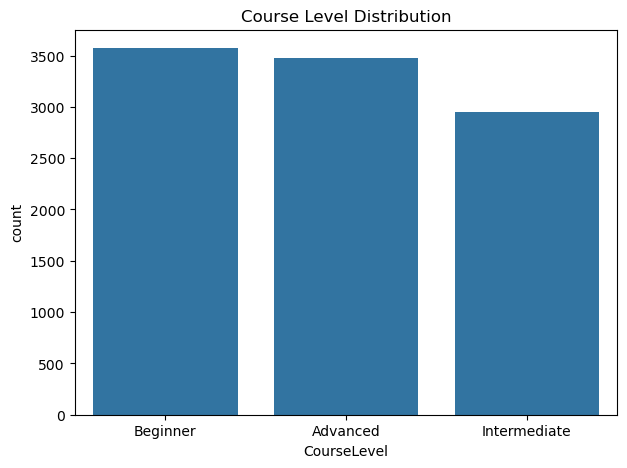

In [40]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=merged_df,
    x="CourseLevel",
    order=merged_df["CourseLevel"].value_counts().index
)

plt.title("Course Level Distribution")

plt.show()

# Chapter 5: Demographic and Course Preference Analysis


## 5.1 Age Group vs Course Category

In [41]:
age_category = pd.crosstab(
    merged_df["AgeGroup"],
    merged_df["CourseCategory"]
)

age_category

CourseCategory,Artificial Intelligence,Business,Cybersecurity,Data Science,Design,Digital Marketing,Finance,Machine Learning,Marketing,Programming,Project Management,Web Development
AgeGroup,,,,,,,,,,,,
<18,129,120,121,114,120,127,136,120,126,109,115,132
18-25,317,307,307,343,311,296,297,305,313,305,296,335
26-35,383,406,391,459,396,385,431,394,367,392,418,377


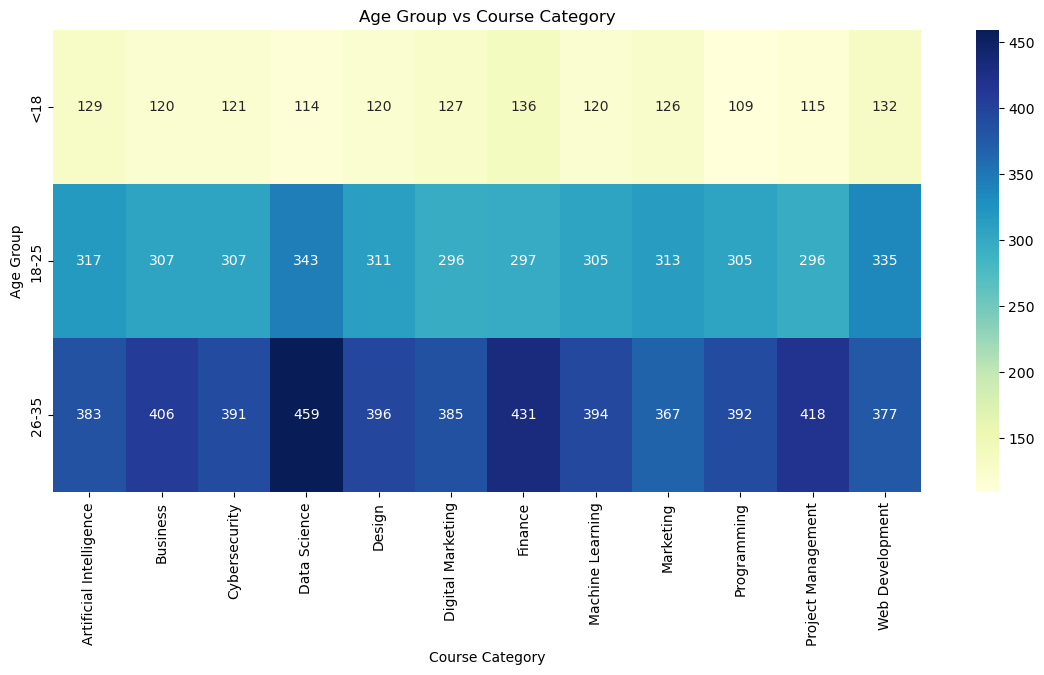

In [42]:
plt.figure(figsize=(14,6))

sns.heatmap(
    age_category,
    annot=True,
    fmt="d",
    cmap="YlGnBu"
)

plt.title("Age Group vs Course Category")

plt.xlabel("Course Category")

plt.ylabel("Age Group")

plt.show()

### Interpretation

The heatmap indicates noticeable differences in enrollment preferences across age groups.

Learners between **26–35 years** contribute the highest enrollments across almost every course category. This is expected because this age group represents the largest learner population on the platform.

Learners below 18 years show comparatively lower enrollments across all categories.

The analysis suggests that EduPro's current audience primarily consists of young professionals who are actively upgrading their skills.

### Business Insight

EduPro should prioritize developing advanced and career-oriented courses targeted toward learners aged 18–35 years, as this demographic represents the largest share of enrollments.

## 5.2 Gender-wise Course Category Preference

In [43]:
gender_category = pd.crosstab(
    merged_df["Gender"],
    merged_df["CourseCategory"]
)

gender_category

CourseCategory,Artificial Intelligence,Business,Cybersecurity,Data Science,Design,Digital Marketing,Finance,Machine Learning,Marketing,Programming,Project Management,Web Development
Gender,,,,,,,,,,,,
Female,413,418,430,479,424,417,451,403,385,420,425,413
Male,416,415,389,437,403,391,413,416,421,386,404,431


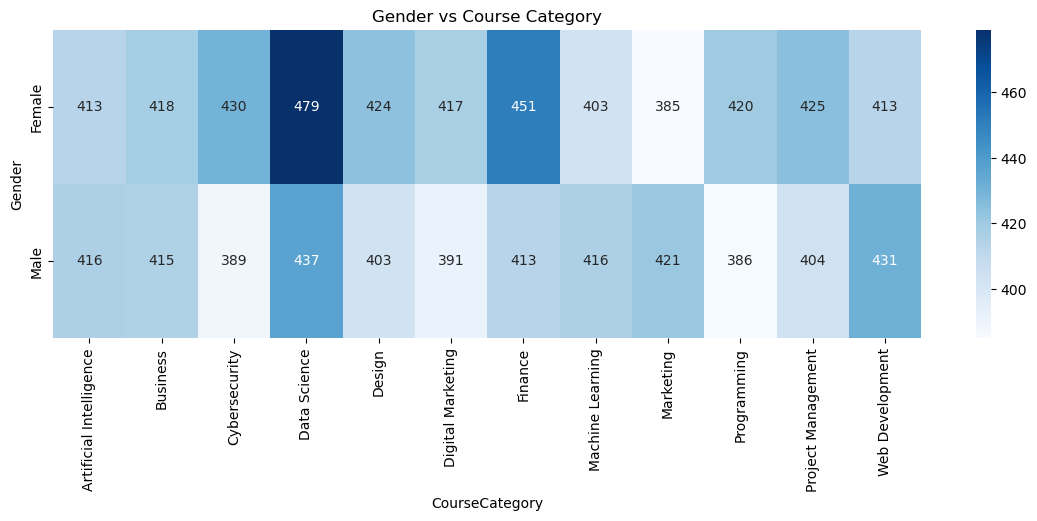

In [44]:
plt.figure(figsize=(14,4))

sns.heatmap(
    gender_category,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Gender vs Course Category")

plt.show()

The enrollment patterns for male and female learners appear relatively balanced across most course categories.

Although minor differences exist in certain categories, no significant gender-specific enrollment bias is observed.

This indicates that EduPro successfully attracts learners from both genders across a diverse range of subjects.

Marketing campaigns should continue to remain gender-inclusive, while category-specific promotional strategies can be developed based on the slight variations observed in learner preferences.

## 5.3 Gender Preference Across Course Levels

In [45]:
gender_level = pd.crosstab(
    merged_df["Gender"],
    merged_df["CourseLevel"]
)

gender_level

CourseLevel,Advanced,Beginner,Intermediate
Gender,,,
Female,1758,1811,1509
Male,1717,1762,1443


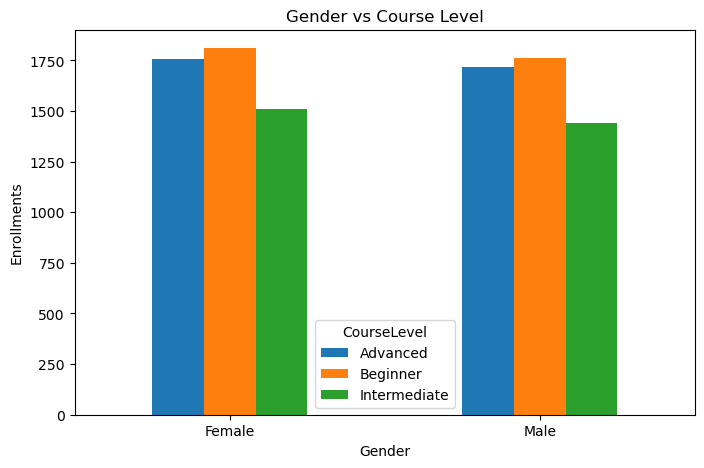

In [46]:
gender_level.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Gender vs Course Level")

plt.ylabel("Enrollments")

plt.xticks(rotation=0)

plt.show()

Both male and female learners participate across all three course levels.

The distribution indicates balanced engagement, suggesting that course difficulty does not significantly vary by gender.

In [47]:
age_level = pd.crosstab(
    merged_df["AgeGroup"],
    merged_df["CourseLevel"]
)

age_level

CourseLevel,Advanced,Beginner,Intermediate
AgeGroup,,,
<18,534,501,434
18-25,1300,1345,1087
26-35,1641,1727,1431


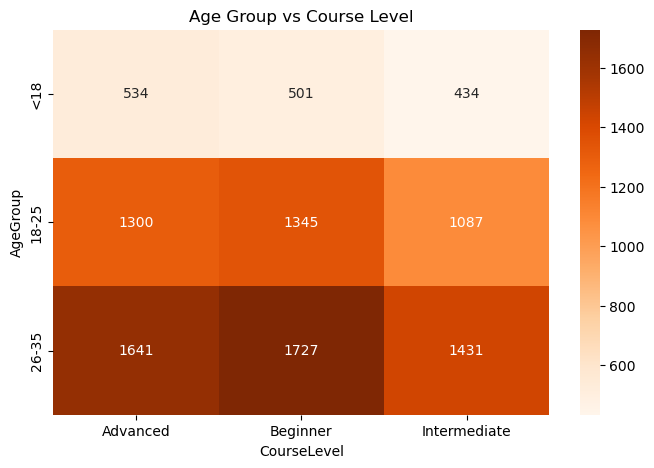

In [48]:
plt.figure(figsize=(8,5))

sns.heatmap(
    age_level,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("Age Group vs Course Level")

plt.show()

Learners aged 26–35 years exhibit the highest enrollments across all course levels.

Beginner-level courses remain popular across every age group, indicating that many learners continue to explore new subject areas regardless of age.

In [49]:
course_type = merged_df["CourseType"].value_counts()

course_type

CourseType
Free    6403
Paid    3597
Name: count, dtype: int64

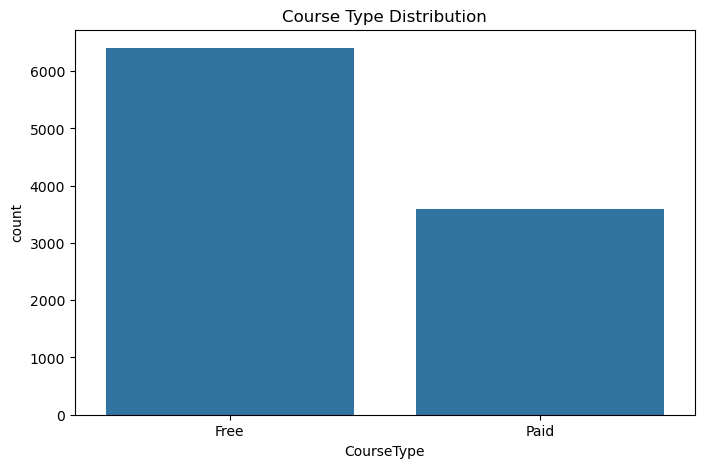

In [50]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=merged_df,
    x="CourseType",
    order=merged_df["CourseType"].value_counts().index
)

plt.title("Course Type Distribution")

plt.show()

The distribution of enrollments across course types highlights learner interest in different learning formats which is free.

The most popular course type- Free represents the preferred learning experience on the EduPro platform.

In [51]:
courses_per_user = merged_df.groupby("UserID")["CourseID"].count()

average_courses = courses_per_user.mean()

print("Average Courses per Learner:", round(average_courses,2))

Average Courses per Learner: 3.33


In [52]:
top_users = merged_df["UserName"].value_counts().head(10)

top_users

UserName
mitchellcarlos    16
karen44           16
juan81            16
smithjames        16
hthomas           16
bernardsexton     16
gordonjulie       16
david25           16
nicole97          16
hallandrea        16
Name: count, dtype: int64

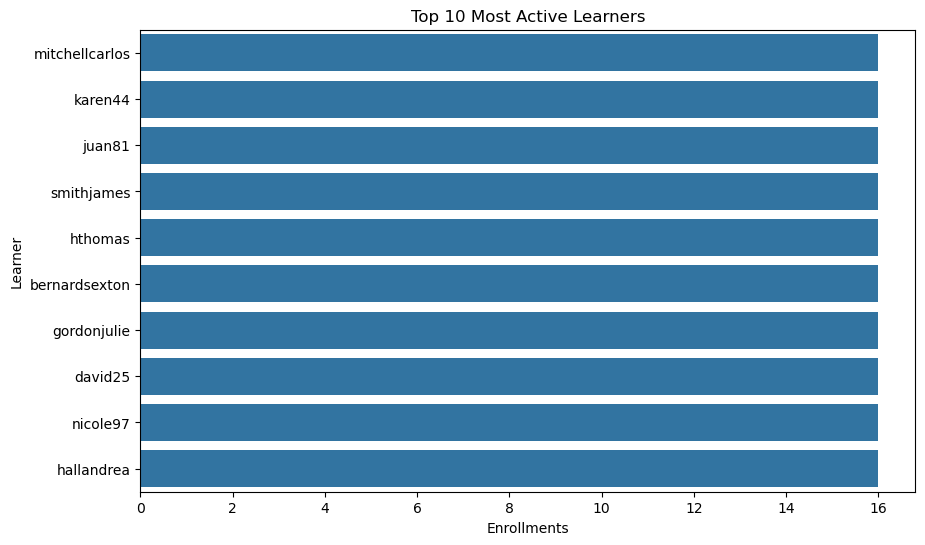

In [53]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=top_users.values,
    y=top_users.index
)

plt.title("Top 10 Most Active Learners")

plt.xlabel("Enrollments")

plt.ylabel("Learner")

plt.show()

A small group of learners contributes a relatively high number of enrollments compared to others.

This indicates the presence of highly engaged users who frequently utilize the EduPro platform.

# Chapter 6: Key Performance Indicators (KPIs)


## KPI 1: Total Learners

In [54]:
total_learners = merged_df["UserID"].nunique()

print("Total Learners :", total_learners)

Total Learners : 3000


The EduPro platform currently serves 3,000 unique learners, indicating a substantial learner base for analysis.

In [55]:
total_courses = merged_df["CourseID"].nunique()

print("Total Courses :", total_courses)

Total Courses : 60


EduPro currently offers 60 unique courses across different categories and difficulty levels.

In [56]:
total_enrollments = merged_df["TransactionID"].nunique()

print("Total Enrollments :", total_enrollments)

Total Enrollments : 10000


The platform recorded 10,000 enrollments, indicating strong learner engagement across multiple courses.

In [57]:
average_courses = (
    merged_df
    .groupby("UserID")["CourseID"]
    .count()
    .mean()
)

print("Average Courses per Learner :", round(average_courses,2))

Average Courses per Learner : 3.33


On average, each learner has enrolled in approximately 3.33 courses, indicating that many learners continue exploring multiple learning opportunities rather than enrolling in only one course.

In [58]:
gender_ratio = (
    merged_df["Gender"]
    .value_counts(normalize=True)
    *100
)

print(gender_ratio)

Gender
Female    50.78
Male      49.22
Name: proportion, dtype: float64


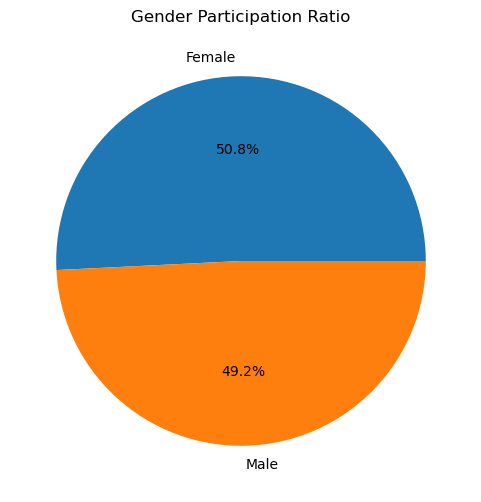

In [59]:
gender_ratio.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.ylabel("")

plt.title("Gender Participation Ratio")

plt.show()


Female learners contribute a slightly higher proportion of enrollments than male learners. However, the participation ratio remains nearly balanced, demonstrating that EduPro successfully attracts learners from both genders.

In [60]:
age_distribution = (
    merged_df["AgeGroup"]
    .value_counts()
    .sort_index()
)

print(age_distribution)

AgeGroup
<18      1469
18-25    3732
26-35    4799
36-45       0
45+         0
Name: count, dtype: int64


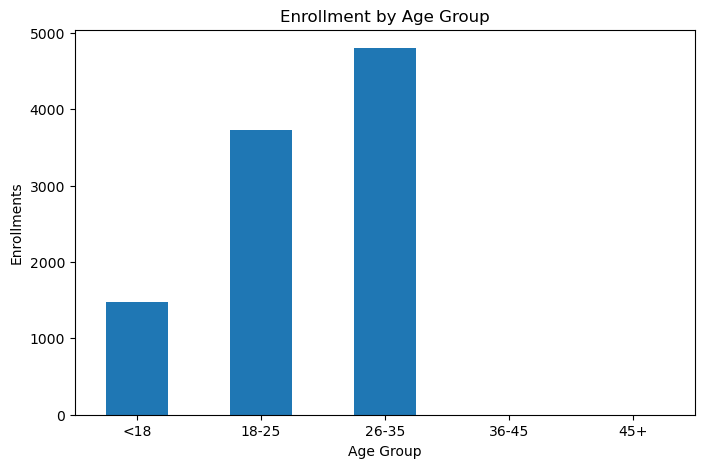

In [61]:
age_distribution.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Enrollment by Age Group")

plt.xlabel("Age Group")

plt.ylabel("Enrollments")

plt.xticks(rotation=0)

plt.show()

Learners aged 26–35 years account for the highest number of enrollments, followed by the 18–25 years age group. This confirms that EduPro primarily serves young adults and working professionals.

In [62]:
category_popularity = (
    merged_df["CourseCategory"]
    .value_counts()
)

print(category_popularity)

CourseCategory
Data Science               916
Finance                    864
Web Development            844
Business                   833
Project Management         829
Artificial Intelligence    829
Design                     827
Cybersecurity              819
Machine Learning           819
Digital Marketing          808
Programming                806
Marketing                  806
Name: count, dtype: int64


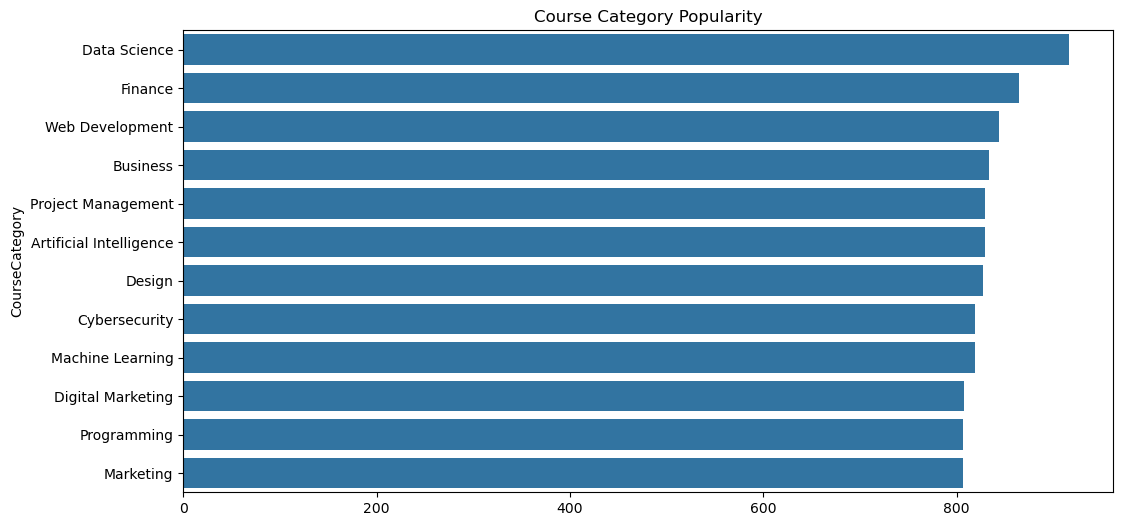

In [63]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=category_popularity.values,
    y=category_popularity.index
)

plt.title("Course Category Popularity")

plt.show()

Data Science is the most popular course category, followed by Finance and Web Development. These categories collectively account for a significant proportion of total enrollments, indicating strong learner demand for technical and career-oriented skills.

In [64]:
level_distribution = (
    merged_df["CourseLevel"]
    .value_counts()
)

print(level_distribution)

CourseLevel
Beginner        3573
Advanced        3475
Intermediate    2952
Name: count, dtype: int64


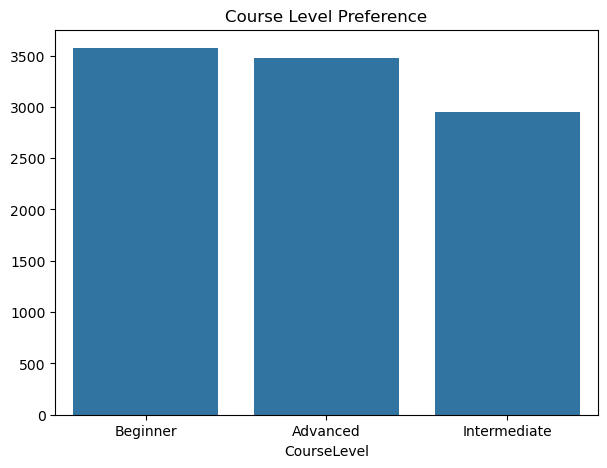

In [65]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=level_distribution.index,
    y=level_distribution.values
)

plt.title("Course Level Preference")

plt.show()

Beginner-level courses have the highest enrollment, followed closely by Advanced courses. This suggests that the EduPro platform successfully caters to both newcomers and experienced learners.

In [66]:
most_popular_course = (
    merged_df["CourseName"]
    .value_counts()
)

print(most_popular_course.head(10))

CourseName
Deep Learning                    334
Natural Language Processing      321
Data Analysis with Python        196
Social Media Strategy            194
Statistical Analysis             192
AI Ethics                        186
Machine Learning Fundamentals    185
Investment Strategies            183
Corporate Finance                182
3D Modeling                      180
Name: count, dtype: int64


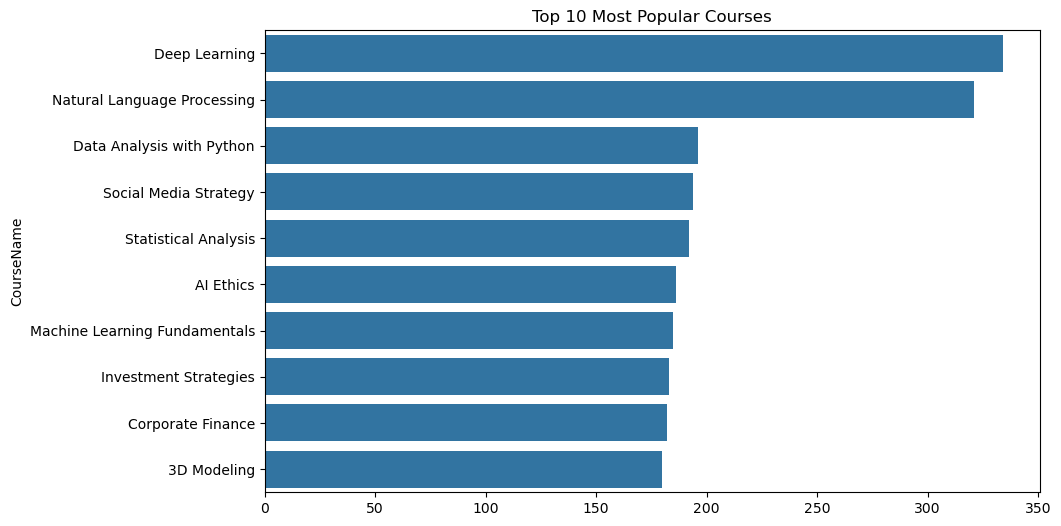

In [67]:
top_courses = merged_df["CourseName"].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_courses.values,
    y=top_courses.index
)

plt.title("Top 10 Most Popular Courses")

plt.show()

The chart identifies the ten courses with the highest enrollments. These courses represent the strongest learner interests and can guide future curriculum expansion.

In [68]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Learners",
        "Total Courses",
        "Total Enrollments",
        "Average Courses per Learner"
    ],
    "Value": [
        total_learners,
        total_courses,
        total_enrollments,
        round(average_courses,2)
    ]
})

kpi_summary

,KPI,Value
0,Total Learners,3000.00
1,Total Courses,60.00
2,Total Enrollments,10000.00
3,Average Courses per Learner,3.33


# Chapter 7: Advanced Visual Analytics


## 7.1 Monthly Enrollment Trend

In [69]:
merged_df["TransactionMonth"] = (
    merged_df["TransactionDate"]
    .dt.to_period("M")
    .astype(str)
)

In [70]:
monthly_enrollments = (
    merged_df
    .groupby("TransactionMonth")
    .size()
    .reset_index(name="Enrollments")
)

monthly_enrollments

,TransactionMonth,Enrollments
0,2025-01,833
1,2025-02,766
2,2025-03,857
3,2025-04,831
4,2025-05,825
5,2025-06,899
6,2025-07,826
7,2025-08,844
8,2025-09,870
9,2025-10,762


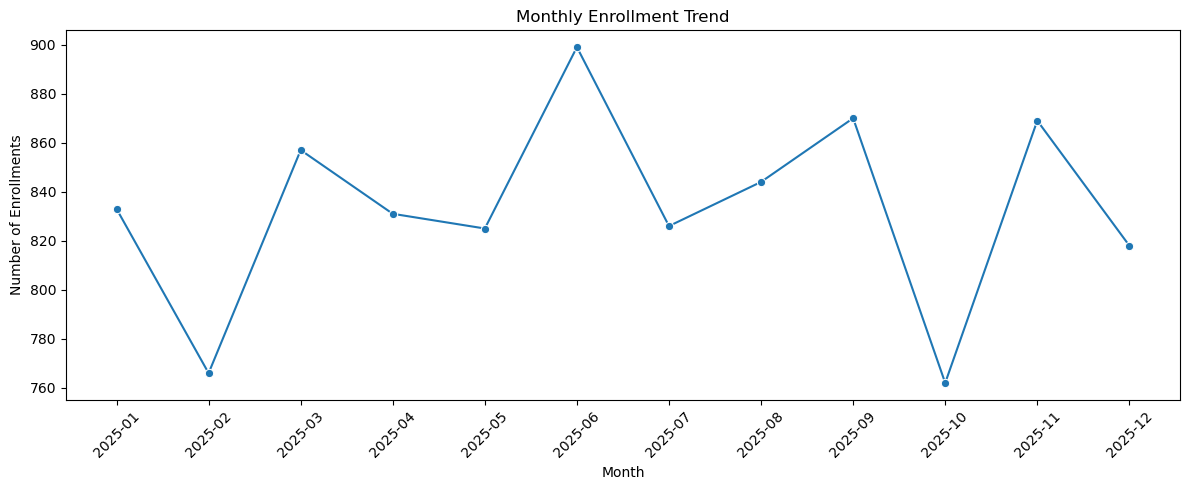

In [71]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=monthly_enrollments,
    x="TransactionMonth",
    y="Enrollments",
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Monthly Enrollment Trend")

plt.xlabel("Month")

plt.ylabel("Number of Enrollments")

plt.tight_layout()

plt.show()

The monthly enrollment trend indicates fluctuations in learner activity throughout the observed period.

Periods with higher enrollments may correspond to promotional campaigns, new course launches, or seasonal learning demand.

## 7.2 Top 10 Most Popular Courses

In [72]:
top_courses = (
    merged_df["CourseName"]
    .value_counts()
    .head(10)
)

top_courses

CourseName
Deep Learning                    334
Natural Language Processing      321
Data Analysis with Python        196
Social Media Strategy            194
Statistical Analysis             192
AI Ethics                        186
Machine Learning Fundamentals    185
Investment Strategies            183
Corporate Finance                182
3D Modeling                      180
Name: count, dtype: int64

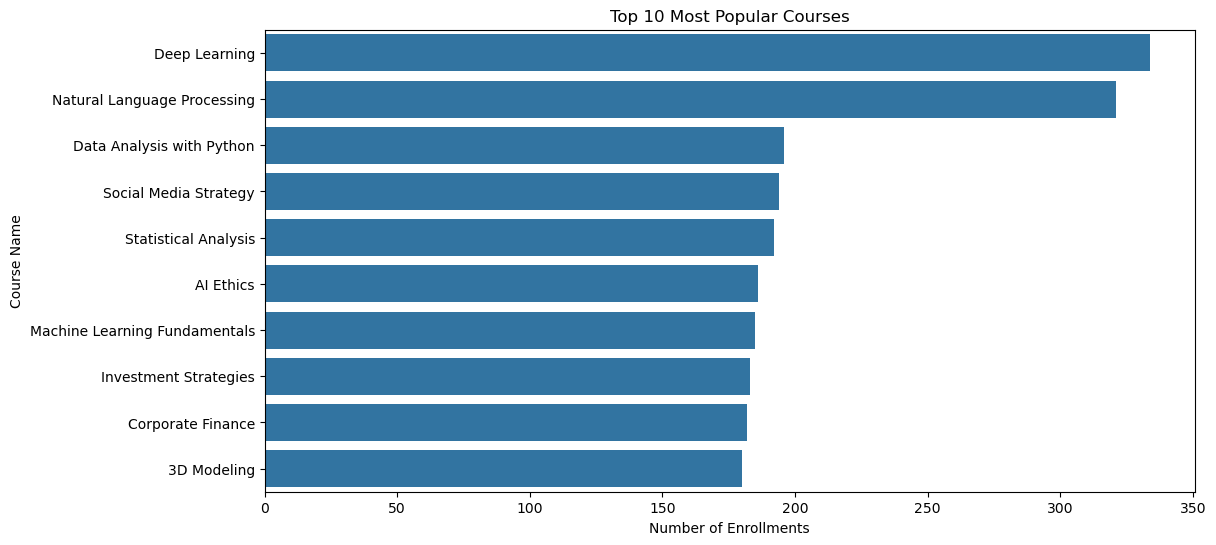

In [73]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_courses.values,
    y=top_courses.index
)

plt.title("Top 10 Most Popular Courses")

plt.xlabel("Number of Enrollments")

plt.ylabel("Course Name")

plt.show()

The chart identifies the courses that attract the highest learner interest.

These courses represent EduPro's strongest educational offerings and can be prioritized for future expansion.

## 7.3 Course Category vs Course Level

In [74]:
category_level = pd.crosstab(
    merged_df["CourseCategory"],
    merged_df["CourseLevel"]
)

category_level

CourseLevel,Advanced,Beginner,Intermediate
CourseCategory,,,
Artificial Intelligence,0,500,329
Business,514,168,151
Cybersecurity,163,179,477
Data Science,166,369,381
Design,672,155,0
Digital Marketing,288,359,161
Finance,172,348,344
Machine Learning,323,155,341
Marketing,498,0,308


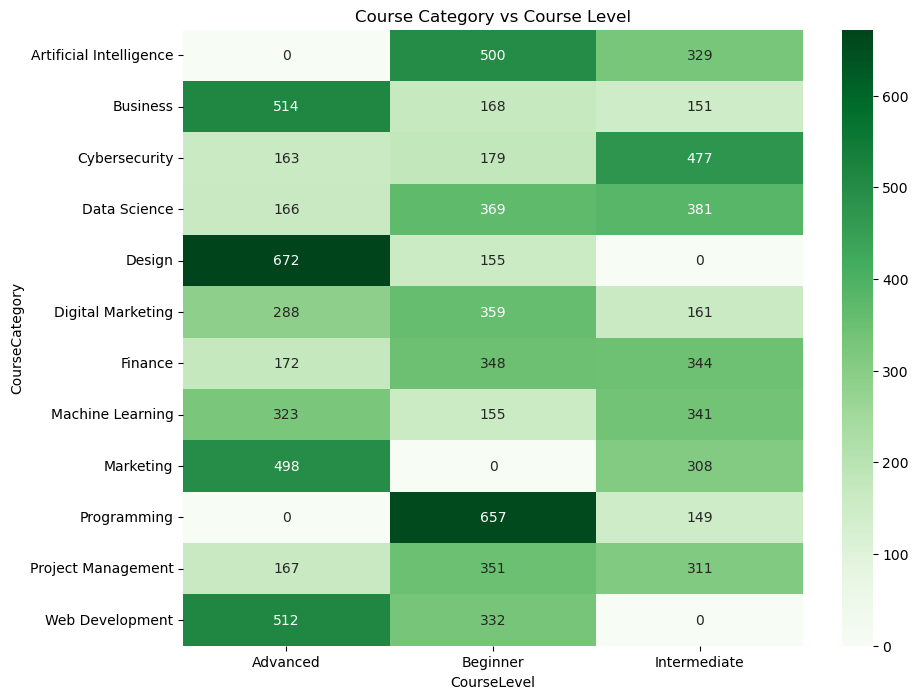

In [75]:
plt.figure(figsize=(10,8))

sns.heatmap(
    category_level,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Course Category vs Course Level")

plt.show()

The heatmap illustrates how different course categories are distributed across Beginner, Intermediate, and Advanced levels.

A balanced distribution suggests that learners can progress within a category as their skills develop.

## 7.4 Learner Engagement Distribution

In [76]:
learner_courses = (
    merged_df
    .groupby("UserID")
    .size()
)

learner_courses.describe()

count    3000.000000
mean        3.333333
std         4.352149
min         1.000000
25%         1.000000
50%         1.000000
75%         3.000000
max        16.000000
dtype: float64

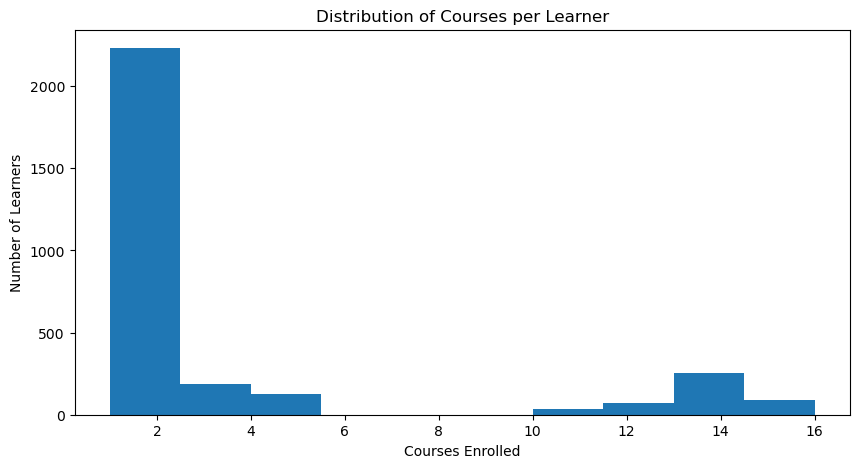

In [77]:
plt.figure(figsize=(10,5))

plt.hist(
    learner_courses,
    bins=10
)

plt.title("Distribution of Courses per Learner")

plt.xlabel("Courses Enrolled")

plt.ylabel("Number of Learners")

plt.show()

The histogram shows how many courses learners typically enroll in.

A concentration around lower values indicates that many learners enroll in only a few courses, while a long tail suggests that a smaller group of highly engaged learners takes multiple courses.

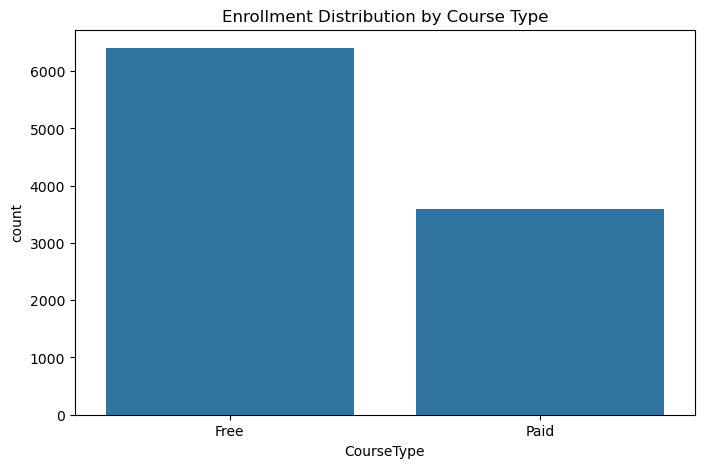

In [78]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=merged_df,
    x="CourseType",
    order=merged_df["CourseType"].value_counts().index
)

plt.title("Enrollment Distribution by Course Type")

plt.show()

The analysis highlights learner preferences for different course delivery formats.

Understanding these preferences helps EduPro design future courses using the formats most valued by learners.

## 7.5 Correlation Analysis

In [79]:
numeric_df = merged_df.select_dtypes(include=["int64", "float64"])

numeric_df.corr()

,Age,Amount,CoursePrice,CourseDuration,CourseRating
Age,1.000000,-0.004630,-0.004630,-0.010838,-0.003945
Amount,-0.004630,1.000000,1.000000,-0.088745,-0.031465
CoursePrice,-0.004630,1.000000,1.000000,-0.088745,-0.031465
CourseDuration,-0.010838,-0.088745,-0.088745,1.000000,0.198433
CourseRating,-0.003945,-0.031465,-0.031465,0.198433,1.000000


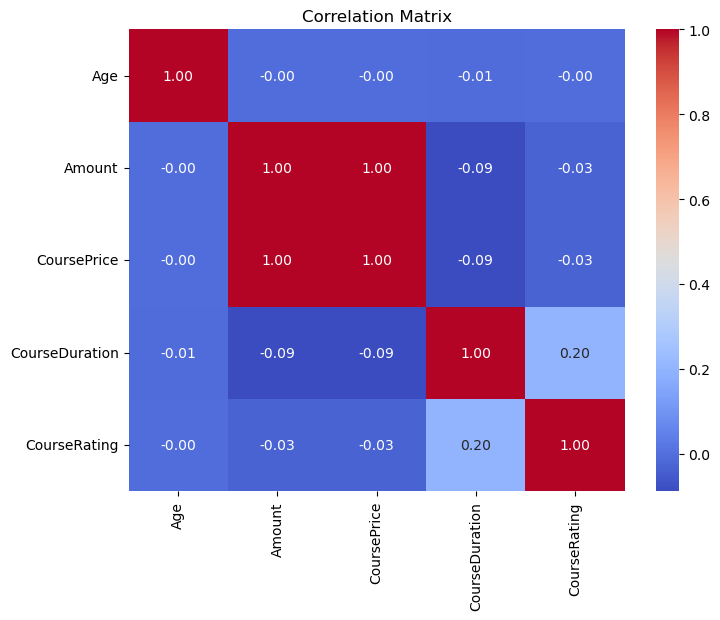

In [80]:
plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [81]:
dashboard_summary = pd.DataFrame({
    "Metric": [
        "Total Learners",
        "Total Courses",
        "Total Enrollments",
        "Average Courses per Learner"
    ],
    "Value": [
        total_learners,
        total_courses,
        total_enrollments,
        round(average_courses,2)
    ]
})

dashboard_summary

,Metric,Value
0,Total Learners,3000.00
1,Total Courses,60.00
2,Total Enrollments,10000.00
3,Average Courses per Learner,3.33
